In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

In [5]:
EnKF_Cov_diff = 1.945
EnKF_PF_RMSE = 1.526
PF_Cov_Diff_95CI = 0.122
PF_RMSE_95CI = 0.164

data_folders = ["2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
                "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_CorrTerms",
                "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_EtE",
                "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_EtE",
                "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_EtE2",
                "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_EtE2",
                ]
data_names = ["CorrTerms ES1",
            "CorrTerms ES2",
            "EtE ES1",
            "EtE ES2",
            "EtE2 ES1",
            "EtE2 ES2"]

result_dict = {
    'cov_diff': {'EnKF': EnKF_Cov_diff, 'PF_95CI': PF_Cov_Diff_95CI},
    'pf_rmse': {'EnKF': EnKF_PF_RMSE, 'PF_95CI': PF_RMSE_95CI},
}
for name, folder in zip(data_names, data_folders):
    data_file = os.path.join("save", folder, "output_records_10.pt")
    data = torch.load(data_file, weights_only=True)
    cov_diff = data["nn"]['cov_diff']
    pf_rmse = data["nn"]['pf_rmse']

    result_dict['cov_diff'][name] = cov_diff
    result_dict['pf_rmse'][name] = pf_rmse

df_results = pd.DataFrame(result_dict)
df_results = df_results[['cov_diff', 'pf_rmse']]

print("Comparison between ES1 and ES2:")
print(df_results)

Comparison between ES1 and ES2:
                cov_diff   pf_rmse
EnKF            1.945000  1.526000
PF_95CI         0.122000  0.164000
CorrTerms ES1   0.789196  0.532986
CorrTerms ES2  10.117352  0.626321
EtE ES1         0.881785  0.691954
EtE ES2         1.371282  0.698244
EtE2 ES1        1.621490  0.910393
EtE2 ES2        1.384443  0.741101


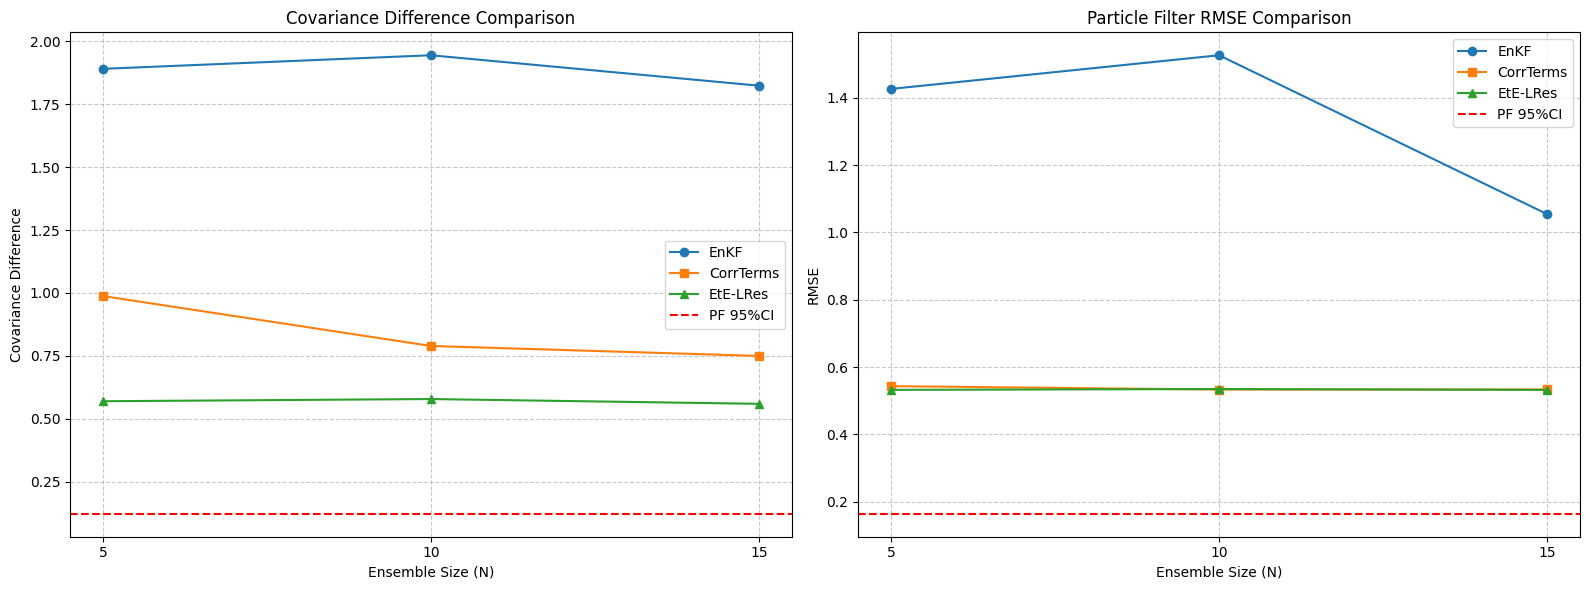

In [8]:
import os
import torch
import matplotlib.pyplot as plt

EnKF_Cov_diff = [1.891, 1.945, 1.824]
EnKF_PF_RMSE = [1.426, 1.526, 1.054]
PF_Cov_Diff_95CI = 0.122
PF_RMSE_95CI = 0.164
ensemble_sizes = [5, 10, 15]

data_folders = [
    "2025-07-06_16-00lorenz63_1.0_5_60_8192_es_joint_CorrTerms",
    "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    "2025-07-06_16-01lorenz63_1.0_15_60_8192_es_joint_CorrTerms",
    "2025-07-06_16-00lorenz63_1.0_5_60_8192_es_joint_EtE-LRes",
    "2025-07-06_12-24lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
    "2025-07-06_16-00lorenz63_1.0_15_60_8192_es_joint_EtE-LRes",
]

results = {
    "CorrTerms": {'cov_diff': [], 'pf_rmse': []},
    "EtE-LRes": {'cov_diff': [], 'pf_rmse': []},
}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    n_value = ensemble_sizes[i % num_sizes]
    filename = f"output_records_{n_value}.pt"
    
    method_name = "CorrTerms" if "CorrTerms" in folder else "EtE-LRes"
    data_file = os.path.join("save", folder, filename)
    data = torch.load(data_file, weights_only=True)
    cov_diff = data["nn"]['cov_diff']
    pf_rmse = data["nn"]['pf_rmse']
    
    results[method_name]['cov_diff'].append(cov_diff)
    results[method_name]['pf_rmse'].append(pf_rmse)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(ensemble_sizes, EnKF_Cov_diff, marker='o', label='EnKF')
ax1.plot(ensemble_sizes, results['CorrTerms']['cov_diff'], marker='s', label='CorrTerms')
ax1.plot(ensemble_sizes, results['EtE-LRes']['cov_diff'], marker='^', label='EtE-LRes')
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(ensemble_sizes, EnKF_PF_RMSE, marker='o', label='EnKF')
ax2.plot(ensemble_sizes, results['CorrTerms']['pf_rmse'], marker='s', label='CorrTerms')
ax2.plot(ensemble_sizes, results['EtE-LRes']['pf_rmse'], marker='^', label='EtE-LRes')
ax2.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Particle Filter RMSE Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('RMSE')
ax2.set_xticks(ensemble_sizes)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()